In [1]:
%load_ext jupyter_black

# base
import os
from pathlib import Path
import warnings
import logging

logging.basicConfig(level="WARNING")
warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)

# data manipulation
import pandas as pd
import numpy as np
import seaborn as sns
import scipy
import matplotlib.pyplot as plt
import itables

itables.init_notebook_mode(all_interactive=True)

warnings.simplefilter("ignore", pd.errors.DtypeWarning)
mlogger = logging.getLogger("matplotlib")
mlogger.setLevel(logging.WARNING)

# single cell
import scanpy as sc
import squidpy as sq
import spatialdata as sd
import spatialdata_plot as sdp
import spatialdata_io
import SpaGCN as spg

# custom
from single_cell.R import *
from single_cell.preprocess import *
from single_cell.plot import *
from single_cell.analysis import *
from spatial_seq.plot import *
from utils import *
mpl.rcdefaults()

# R
import rpy2.robjects as ro
from rpy2.robjects.conversion import localconverter
converter = get_converter()
%load_ext rpy2.ipython

# analysis & device specific
%matplotlib inline
CORES = 10
DATADIR = Path("../../../data")
REFDIR = Path("../../../references")

/Users/ehung/Documents/labs/molofsky/spatial_seq/.venv/lib/python3.12/site-packages/louvain/Optimiser.py:114: SyntaxWarning: invalid escape sequence '\s'
  """ Optimise the given partitions simultaneously.
/Users/ehung/Documents/labs/molofsky/spatial_seq/.venv/lib/python3.12/site-packages/scvi/__init__.py:31: DeprecationWarning: scvi is deprecated, please uninstall scvi via `pip uninstall scvi` and install the new scvi-tools package at github.com/YosefLab/scvi-tools
  warnings.warn(deprecation_msg, DeprecationWarning)
/Users/ehung/Documents/labs/molofsky/spatial_seq/.venv/lib/python3.12/site-packages/phenograph/cluster.py:13: DeprecationWarning: Please import `spmatrix` from the `scipy.sparse` namespace; the `scipy.sparse.base` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.sparse.base import spmatrix


# SpaceGCN

In [2]:
# LOAD PROCESSED
sdata = sd.read_zarr(DATADIR / "processed" / "spatial" / "raws" / "COMBINED")
samples = list(sdata["square_008um"].obs["Identifier"].unique())

## QC

Remaining bins: 1765959



AnnData object with n_obs × n_vars = 1765959 × 19036
    obs: 'in_tissue', 'array_row', 'array_col', 'location_id', 'region', 'Identifier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mito'
    var: 'igs', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mito'
    uns: 'spatialdata_attrs'
    obsm: 'spatial', 'igs'
    layers: 'counts'

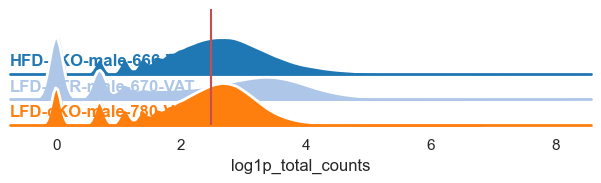

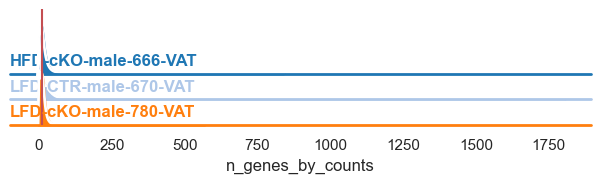

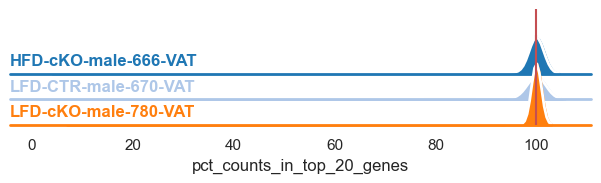

In [17]:
filters = {"GenesPerCell": 0, "ReadsPerCell": 30, "CellsPerGene": 10, "Mito%": 15}

adata = sdata["segmented_bins"].copy()

# # clean mitochondrial genes
# adata.var["mito"] = adata.var_names.str.startswith("mt-")
# adata.obsm["mito"] = adata[:, adata.var["mito"].values].X.toarray()
# adata = adata[:, ~adata.var["mito"].values]

# clean Ig genes
adata.var["igs"] = adata.var_names.str.contains("Igh|Igk|Jchain")
adata.obsm["igs"] = adata[:, adata.var["igs"].values].X.toarray()
adata = adata[:, ~adata.var["igs"].values]

sc.pp.calculate_qc_metrics(adata, inplace=True, percent_top=[20])
Filter_GeneGroup(adata)

# Filter_QC(
#     adata,
#     GenePerCell=filters["GenesPerCell"],
#     CountPerCell=filters["ReadsPerCell"],
#     CellPerGene=filters["CellsPerGene"],
#     verbose=True,
# )
# Filter_GeneGroup(
#     adata,
#     key="mito",
#     marker="mt",
#     verbose=True,
#     perc_threshold=filters["Mito%"],
# )

print(f"Remaining bins: {adata.shape[0]}\n")

groupby = "Identifier"
check_QCPlot(adata.obs, "log1p_total_counts", groupby)
check_QCPlot(adata.obs, "n_genes_by_counts", groupby)
check_QCPlot(adata.obs, "pct_counts_in_top_20_genes", groupby)
adata

In [18]:
np.mean(adata.obs["n_genes_by_counts"])

np.float64(18.00447915268701)

## START ANALYSIS

In [ ]:
import SpaGCN as spg
import numpy as np
from scipy.sparse import block_diag

def run_spagcn_combined(adata, batch_col='Identifier', n_clusters=7, p=0.5):
    adata = adata.copy()
    
    adata.obs['x_pixel'] = adata.obsm['spatial'][:, 0]
    adata.obs['y_pixel'] = adata.obsm['spatial'][:, 1]
    adata.obs['x_array'] = adata.obs['x_pixel'].copy()
    adata.obs['y_array'] = adata.obs['y_pixel'].copy()
    
    spg.prefilter_genes(adata, min_cells=3)
    spg.prefilter_specialgenes(adata)
    
    batch_labels = adata.obs[batch_col].values
    dataset_names = adata.obs[batch_col].unique()
    x_pixel = adata.obs['x_pixel'].values
    y_pixel = adata.obs['y_pixel'].values
    
    adj_matrices = []
    for dataset_name in dataset_names:
        mask = batch_labels == dataset_name
        x_batch = x_pixel[mask]
        y_batch = y_pixel[mask]
        adj_batch = spg.calculate_adj_matrix(x=x_batch, y=y_batch, histology=False)
        adj_matrices.append(adj_batch)
    
    adj = block_diag(adj_matrices, format='csr')
    
    l = spg.search_l(p, adj, start=0.01, end=1000, tol=0.01, max_run=100)
    res = spg.search_res(adata, adj, l, n_clusters, start=0.7, step=0.1, 
                        tol=5e-3, lr=0.05, max_epochs=20, r_seed=100, t_seed=100, n_seed=100)
    
    clf = spg.SpaGCN()
    clf.set_l(l)
    clf.train(adata, adj, init_spa=True, init="louvain", res=res, 
              tol=5e-3, lr=0.05, max_epochs=200)
    y_pred, prob = clf.predict()
    
    adata.obs['pred'] = y_pred
    adata.obs['pred'] = adata.obs['pred'].astype('category')
    
    refined_pred = spg.refine(sample_id=adata.obs.index.tolist(), 
                              pred=adata.obs['pred'].tolist(), 
                              dis=adj, shape='hexagon')
    adata.obs['refined_pred'] = refined_pred
    adata.obs['refined_pred'] = adata.obs['refined_pred'].astype('category')
    
    return adata

# Usage:
dataset_names = samples
combined_result = run_spagcn_combined(sdata["segmented_bins"], n_clusters=5)

# # View predictions per dataset:
# result[result.obs['Identifier'] == 'dataset1'].obs['refined_pred']

Calculateing adj matrix using xy only...


In [ ]:
sdata["square_008um"].obs["spacegcn"] = spg.detect_spatial_domains_ez_mode(
    sdata["square_008um"],
    sdata["square_008um"],
    x_array, y_array,
    x_pixel, y_pixel,
    n_clusters=7, histology=True,
    s=1, b=49, p=0.5, r_seed=100,
    t_seed=100, n_seed=100)

In [25]:
imgs = [sdata[f"hires_image-{sample}"] for sample in samples]
imgs

[<xarray.DataArray 'image' (c: 3, y: 4960, x: 6000)> Size: 89MB
 dask.array<from-zarr, shape=(3, 4960, 6000), dtype=uint8, chunksize=(3, 4960, 6000), chunktype=numpy.ndarray>
 Coordinates:
   * c        (c) <U1 12B 'r' 'g' 'b'
   * y        (y) float64 40kB 0.5 1.5 2.5 3.5 ... 4.958e+03 4.958e+03 4.96e+03
   * x        (x) float64 48kB 0.5 1.5 2.5 3.5 ... 5.998e+03 5.998e+03 6e+03
 Attributes:
     transform:  {'LFD-CTR-male-670-VAT_downscaled_hires': Identity , 'LFD-CTR...,
 <xarray.DataArray 'image' (c: 3, y: 6000, x: 5098)> Size: 92MB
 dask.array<from-zarr, shape=(3, 6000, 5098), dtype=uint8, chunksize=(3, 6000, 5098), chunktype=numpy.ndarray>
 Coordinates:
   * c        (c) <U1 12B 'r' 'g' 'b'
   * y        (y) float64 48kB 0.5 1.5 2.5 3.5 ... 5.998e+03 5.998e+03 6e+03
   * x        (x) float64 41kB 0.5 1.5 2.5 3.5 ... 5.096e+03 5.096e+03 5.098e+03
 Attributes:
     transform:  {'HFD-cKO-male-666-VAT_downscaled_hires': Identity , 'HFD-cKO...,
 <xarray.DataArray 'image' (c: 3, y: 45

In [80]:
sdata

SpatialData object, with associated Zarr store: /Users/ehung/Documents/labs/molofsky/spatial_seq/data/processed/spatial/raws/COMBINED
├── Images
│     ├── 'cytassist_image-HFD-cKO-male-666-VAT': DataArray[cyx] (3, 2999, 3196)
│     ├── 'cytassist_image-LFD-CTR-male-670-VAT': DataArray[cyx] (3, 3000, 3200)
│     ├── 'cytassist_image-LFD-cKO-male-780-VAT': DataArray[cyx] (3, 2998, 3200)
│     ├── 'hires_image-HFD-cKO-male-666-VAT': DataArray[cyx] (3, 6000, 5098)
│     ├── 'hires_image-LFD-CTR-male-670-VAT': DataArray[cyx] (3, 4960, 6000)
│     ├── 'hires_image-LFD-cKO-male-780-VAT': DataArray[cyx] (3, 4596, 6000)
│     ├── 'lowres_image-HFD-cKO-male-666-VAT': DataArray[cyx] (3, 600, 510)
│     ├── 'lowres_image-LFD-CTR-male-670-VAT': DataArray[cyx] (3, 496, 600)
│     └── 'lowres_image-LFD-cKO-male-780-VAT': DataArray[cyx] (3, 460, 600)
├── Shapes
│     ├── 'SHAPE_square_002um-HFD-cKO-male-666-VAT': GeoDataFrame shape: (8705282, 1) (2D shapes)
│     ├── 'SHAPE_square_002um-LFD-CTR-male-6

INFO     Rasterizing image for faster rendering.                                                                   


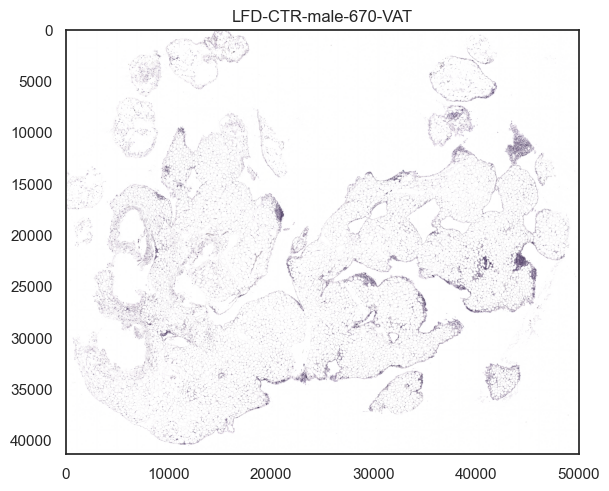

In [83]:
sdata.pl.render_images(f"hires_image-{samples[0]}").pl.show(
    coordinate_systems=f"{samples[0]}"
)

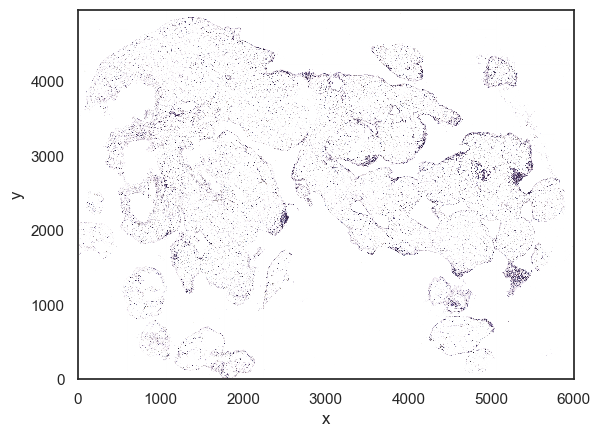

In [87]:
import xarray as xr

xr.plot.imshow(imgs[0])

In [89]:
def extract_color(x_pixel=None, y_pixel=None, image=None, beta=49):
    # beta to control the range of neighbourhood when calculate grey vale for one spot
    beta_half = round(beta / 2)
    g = []
    for y in range(len(y_pixel)):
        for x in range(len(x_pixel)):
            nbs = image[
                max(0, x - beta_half) : min(image.shape[0], x + beta_half + 1),
                max(0, y - beta_half) : min(image.shape[1], y + beta_half + 1),
            ]
            g.append(np.mean(np.mean(nbs, axis=0), axis=0))
    c0, c1, c2 = [], [], []
    for i in g:
        c0.append(i[0])
        c1.append(i[1])
        c2.append(i[2])
    c0 = np.array(c0)
    c1 = np.array(c1)
    c2 = np.array(c2)
    c3 = (c0 * np.var(c0) + c1 * np.var(c1) + c2 * np.var(c2)) / (
        np.var(c0) + np.var(c1) + np.var(c2)
    )
    return c3


extract_color(
    x_pixel=imgs[0]["x"].to_numpy(),
    y_pixel=imgs[0]["y"].to_numpy(),
    image=imgs[0].T.to_numpy(),
)

KeyboardInterrupt: 

In [ ]:
b=49
s=1
x_pixel1=adata1.obs["x4"].tolist()
y_pixel1=adata1.obs["x5"].tolist()
adata1.obs["color"]=spg.extract_color(x_pixel=x_pixel1, y_pixel=y_pixel1, image=img1, beta=b)
z_scale=np.max([np.std(x_pixel1), np.std(y_pixel1)])*s
adata1.obs["z"]=(adata1.obs["color"]-np.mean(adata1.obs["color"]))/np.std(adata1.obs["color"])*z_scale

x_pixel2=adata2.obs["x4"].tolist()
y_pixel2=adata2.obs["x5"].tolist()
adata2.obs["color"]=spg.extract_color(x_pixel=x_pixel2, y_pixel=y_pixel2, image=img2, beta=b)
z_scale=np.max([np.std(x_pixel2), np.std(y_pixel2)])*s
adata2.obs["z"]=(adata2.obs["color"]-np.mean(adata2.obs["color"]))/np.std(adata2.obs["color"])*z_scale
del img1, img2